# NYC shooting visuals → web export

1. **Run the first code cell below** — writes `generated/dashboard_data.json` (stdlib only, no extra installs).
2. **Optional:** run the matplotlib cell — saves PNGs under `generated/figures/`.

Set your Jupyter **working directory** to **`final_project`** (the folder that contains `data/`).

`index_plan_v2.html` loads `generated/dashboard_data.json` when it exists; otherwise it reads the CSVs in `data/`.

**Optional plotting:** `pip install matplotlib`

In [5]:
"""Build generated/dashboard_data.json (stdlib only). Run notebook from final_project/."""

from pathlib import Path
import csv
import json
import math
from collections import Counter, defaultdict

ROOT = Path.cwd().resolve()
assert (ROOT / "data" / "nypd_shootings_combined.csv").exists(), (
    "Working directory must be final_project/ (folder that contains data/)."
)

TREND_START_YEAR = 2006
TREND_END_YEAR = 2025

BOROS = ["BRONX", "BROOKLYN", "MANHATTAN", "QUEENS", "STATEN ISLAND"]

DOW = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]


def _truthy(x: str) -> bool:
    return str(x).strip().lower() in ("true", "1", "yes", "y")


def _int(x, default=0) -> int:
    try:
        if x is None or x == "":
            return default
        return int(float(x))
    except (TypeError, ValueError):
        return default


def _float_opt(x):
    try:
        if x is None or x == "":
            return None
        v = float(x)
        if math.isnan(v):
            return None
        return v
    except (TypeError, ValueError):
        return None


def parse_row(r: dict) -> dict:
    lat = _float_opt(r.get("Latitude"))
    lon = _float_opt(r.get("Longitude"))
    return {
        "key": str(r["INCIDENT_KEY"]),
        "date": str(r.get("OCCUR_DATE", "")),
        "boro": str(r.get("BORO", "")),
        "precinct": _int(r.get("PRECINCT")),
        "locClass": str(r.get("LOC_CLASSFCTN_DESC", "") or ""),
        "lat": lat,
        "lon": lon,
        "year": _int(r.get("year")),
        "month": _int(r.get("month")),
        "dow": str(r.get("day_of_week", "") or ""),
        "hour": _int(r.get("hour")),
        "numVictims": _int(r.get("num_victims")),
        "numMurdered": _int(r.get("num_murdered")),
        "fatal": _truthy(str(r.get("has_fatality", ""))),
        "victimAgeGroups": str(r.get("victim_age_groups", "") or ""),
        "victimSexes": str(r.get("victim_sexes", "") or ""),
        "hasOffenderData": _truthy(str(r.get("has_offender_data", ""))),
    }


def aggregate_incidents(incidents: list[dict]) -> dict:
    I = [d for d in incidents if TREND_START_YEAR <= d["year"] <= TREND_END_YEAR]

    yearly_map: dict[int, dict] = defaultdict(
        lambda: {"n": 0, "victims": 0, "murdered": 0},
    )
    for d in I:
        y = d["year"]
        yearly_map[y]["n"] += 1
        yearly_map[y]["victims"] += d["numVictims"]
        yearly_map[y]["murdered"] += d["numMurdered"]

    yearly = []
    for y in sorted(yearly_map):
        v = yearly_map[y]
        rate = (v["murdered"] / v["victims"]) if v["victims"] else 0.0
        yearly.append({"year": y, **v, "rate": rate})

    monthly_map = Counter(d["month"] for d in I)
    monthly = [{"month": m, "n": monthly_map[m]} for m in range(1, 13)]

    dh_map: dict[tuple[str, int], int] = defaultdict(int)
    for d in I:
        dh_map[(d["dow"], d["hour"])] += 1

    dh_rows = []
    for di, day in enumerate(DOW):
        for h in range(24):
            dh_rows.append({"day": day, "di": di, "hour": h, "n": dh_map.get((day, h), 0)})

    by_boro_ct = Counter(d["boro"] for d in I)
    by_boro = [{"boro": b, "n": by_boro_ct[b]} for b in sorted(by_boro_ct, key=lambda x: -by_boro_ct[x])]

    by_prec_ct = Counter(d["precinct"] for d in I)
    by_precinct = [
        {"precinct": p, "n": by_prec_ct[p]}
        for p in sorted(by_prec_ct, key=lambda x: -by_prec_ct[x])
    ]

    boro_year_rows = []
    for y in range(TREND_START_YEAR, TREND_END_YEAR + 1):
        slice_y = [d for d in I if d["year"] == y]
        row = {"year": y, "NYC": len(slice_y)}
        for b in BOROS:
            row[b] = sum(1 for d in slice_y if d["boro"] == b)
        boro_year_rows.append(row)

    coords = []
    for d in incidents:
        lat, lon = d["lat"], d["lon"]
        if lat is None or lon is None:
            continue
        if 40 < lat < 41:
            coords.append(
                {
                    "lat": lat,
                    "lon": lon,
                    "year": d["year"],
                    "boro": d["boro"],
                    "precinct": d["precinct"],
                }
            )

    return {
        "yearly": yearly,
        "monthly": monthly,
        "dayHour": dh_rows,
        "dows": DOW,
        "byBoro": by_boro,
        "byPrecinct": by_precinct,
        "boroYearRows": boro_year_rows,
        "coords": coords,
    }


def victim_rollup(victims: list[dict]) -> tuple[list[dict], list[dict]]:
    age_order = ["<18", "18-24", "25-44", "45-64", "65+", "UNKNOWN"]
    by_age = defaultdict(list)
    for v in victims:
        by_age[v["age"]].append(v)

    out_age = []
    for a in age_order:
        g = by_age.get(a, [])
        if not g:
            continue
        n = len(g)
        killed = sum(1 for x in g if x["murder"])
        out_age.append({"age": a, "n": n, "killed": killed, "rate": killed / n if n else 0.0})

    sex_ct = Counter(v["sex"] for v in victims if v["sex"] in ("MALE", "FEMALE"))
    out_sex = [{"sex": s, "n": sex_ct[s]} for s in sorted(sex_ct, key=lambda x: -sex_ct[x])]
    return out_age, out_sex


def load_csv(path: Path) -> list[dict]:
    with open(path, newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))


# --- build bundle ---
data_dir = ROOT / "data"
out_dir = ROOT / "generated"
out_dir.mkdir(parents=True, exist_ok=True)

shoot_rows = load_csv(data_dir / "nypd_shootings_combined.csv")
incidents = [parse_row(r) for r in shoot_rows]

agg = aggregate_incidents(incidents)

vic_rows = load_csv(data_dir / "nypd_victims_clean.csv")
victims = [
    {
        "incident": str(r["INCIDENT_KEY"]),
        "age": str(r.get("VICTIM_AGE_GROUP", "") or ""),
        "sex": str(r.get("VICTIM_SEX", "") or ""),
        "race": str(r.get("VICTIM_RACE", "") or ""),
        "murder": _truthy(str(r.get("is_murder", ""))),
    }
    for r in vic_rows
]

va, vs = victim_rollup(victims)
agg["victimsByAge"] = [x for x in va if x["age"] != "UNKNOWN"]
agg["victimsBySex"] = vs

off_rows = load_csv(data_dir / "nypd_offenders_clean.csv")
offenders_min = [{"age": str(r.get("PERP_AGE_GROUP", "") or "UNKNOWN")} for r in off_rows]

with open(data_dir / "legislation_events.json", encoding="utf-8") as f:
    legislation = json.load(f)

payload = {
    "meta": {
        "trend_start_year": TREND_START_YEAR,
        "trend_end_year": TREND_END_YEAR,
        "generator": "build_visuals.ipynb",
    },
    "legislation": legislation,
    "incidents": incidents,
    "agg": agg,
    "victims": victims,
    "offenders_minimal": offenders_min,
}

out_json = out_dir / "dashboard_data.json"
with open(out_json, "w", encoding="utf-8") as f:
    json.dump(payload, f, ensure_ascii=False, allow_nan=False)

print(f"Wrote {out_json} ({out_json.stat().st_size // 1024} KB)")

Wrote /Users/saevarreynis/Desktop/social-data-analysis-and-visualization-02806-assignments/final_project/generated/dashboard_data.json (12879 KB)


## Optional static figures (PNG)

These mirror key charts for reports; the live site still uses D3 when you load the JSON bundle.

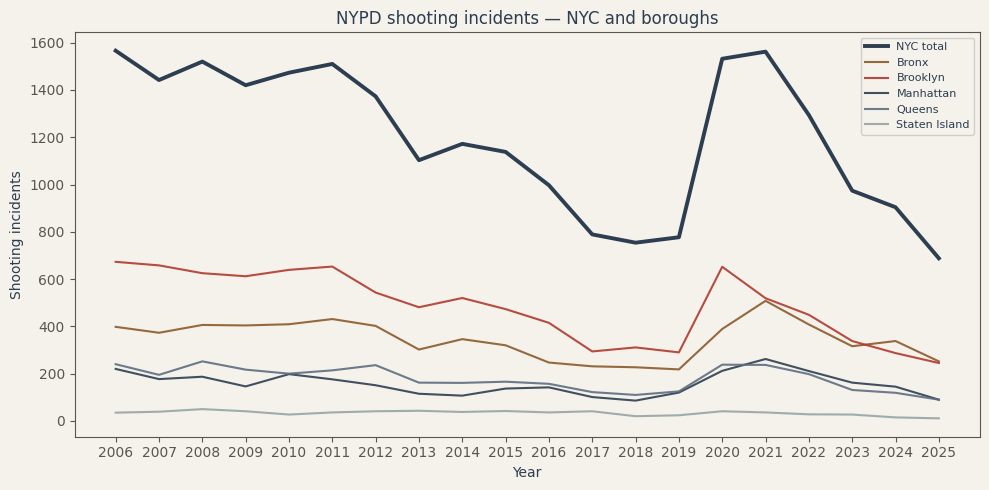

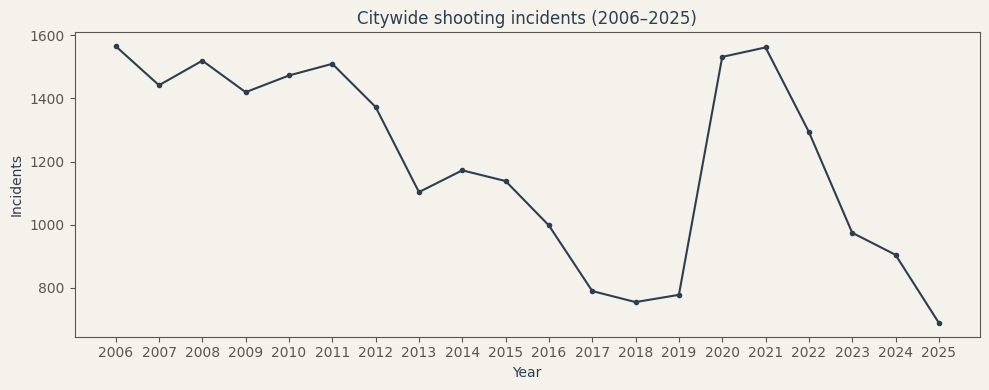

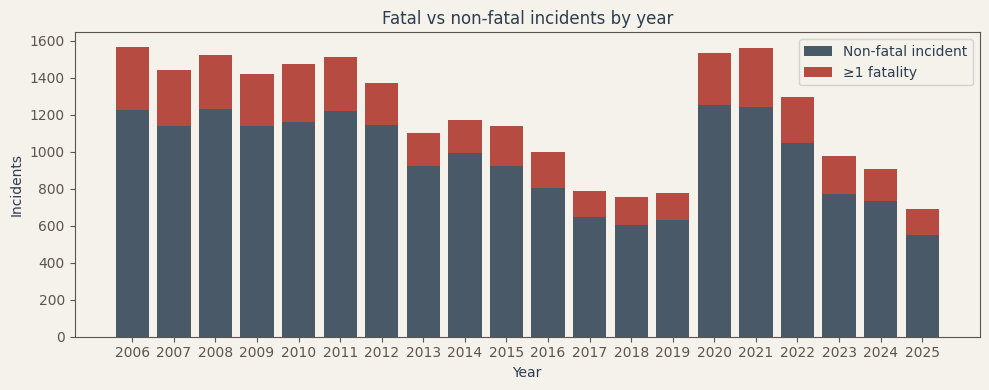

Saved PNGs to /Users/saevarreynis/Desktop/social-data-analysis-and-visualization-02806-assignments/final_project/generated/figures


In [6]:
import json
from pathlib import Path

import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
FIG = ROOT / "generated" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

BG = "#f5f1eb"
FG = "#2c3e50"
ACCENT = "#b03a2e"
MUTED = "#5a554e"

plt.rcParams.update(
    {
        "figure.facecolor": BG,
        "axes.facecolor": BG,
        "axes.edgecolor": MUTED,
        "axes.labelcolor": FG,
        "text.color": FG,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "font.size": 10,
    }
)

dash = json.loads((ROOT / "generated" / "dashboard_data.json").read_text(encoding="utf-8"))
agg = dash["agg"]
meta = dash["meta"]
y0, y1 = meta["trend_start_year"], meta["trend_end_year"]

# --- Borough lines + NYC total ---
boro_rows = agg["boroYearRows"]
years = [r["year"] for r in boro_rows]
plt.figure(figsize=(10, 5))
plt.plot(years, [r["NYC"] for r in boro_rows], color=FG, linewidth=2.8, label="NYC total")
colors = {"BRONX": "#8b5a2b", "BROOKLYN": ACCENT, "MANHATTAN": FG, "QUEENS": "#5d6d7e", "STATEN ISLAND": "#95a5a6"}
for b, c in colors.items():
    plt.plot(years, [r[b] for r in boro_rows], color=c, linewidth=1.5, alpha=0.9, label=b.title())
plt.xlabel("Year")
plt.ylabel("Shooting incidents")
plt.title("NYPD shooting incidents — NYC and boroughs")
plt.legend(loc="upper right", fontsize=8, framealpha=0.9)
plt.xticks(range(min(years), max(years) + 1))
plt.tight_layout()
plt.savefig(FIG / "borough_trends.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Yearly incidents ---
yr = agg["yearly"]
plt.figure(figsize=(10, 4))
plt.plot([r["year"] for r in yr], [r["n"] for r in yr], color=FG, marker="o", markersize=3)
plt.xlabel("Year")
plt.ylabel("Incidents")
plt.title(f"Citywide shooting incidents ({y0}–{y1})")
plt.xticks([r["year"] for r in yr])
plt.tight_layout()
plt.savefig(FIG / "citywide_trend.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Fatal vs non-fatal (incident-level, same rule as page: has_fatality) ---
fatal_by_y = {}
nf_by_y = {}
for row in dash["incidents"]:
    y = row["year"]
    if y < y0 or y > y1:
        continue
    if row["fatal"]:
        fatal_by_y[y] = fatal_by_y.get(y, 0) + 1
    else:
        nf_by_y[y] = nf_by_y.get(y, 0) + 1

ys = list(range(y0, y1 + 1))
fatal = [fatal_by_y.get(y, 0) for y in ys]
nf = [nf_by_y.get(y, 0) for y in ys]
plt.figure(figsize=(10, 4))
plt.bar(ys, nf, color=FG, alpha=0.85, label="Non-fatal incident")
plt.bar(ys, fatal, bottom=nf, color=ACCENT, alpha=0.9, label="≥1 fatality")
plt.xlabel("Year")
plt.ylabel("Incidents")
plt.title("Fatal vs non-fatal incidents by year")
plt.legend()
plt.xticks(ys)
plt.tight_layout()
plt.savefig(FIG / "fatal_stack.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved PNGs to", FIG)